In [14]:
# Data Ingestion

import pandas as pd
df=pd.read_csv("C:\\Users\\lenovo\\Downloads\\Afficionado Coffee Roasters.csv")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11 AM,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04 AM,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24 AM,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
transaction_id      149116 non-null int64
year                149116 non-null int64
transaction_time    149116 non-null object
transaction_qty     149116 non-null int64
store_id            149116 non-null int64
store_location      149116 non-null object
product_id          149116 non-null int64
unit_price          149116 non-null float64
product_category    149116 non-null object
product_type        149116 non-null object
product_detail      149116 non-null object
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


In [32]:
## validate timestamp formats

df["transaction_time"]=pd.to_datetime(df["transaction_time"],"format= H% M% S% p%")
df["hour"]=df["transaction_time"].dt.hour


In [33]:
df["hour"]

0          7
1          7
2          7
3          7
4          7
          ..
149111    20
149112    20
149113    20
149114    20
149115    20
Name: hour, Length: 149116, dtype: int64

In [34]:
df["transaction_time"].head()

0   2026-06-22 07:06:11
1   2026-06-22 07:08:56
2   2026-06-22 07:14:04
3   2026-06-22 07:20:24
4   2026-06-22 07:22:41
Name: transaction_time, dtype: datetime64[ns]

In [73]:
# Checking for missing transaction_id
df["transaction_id"].isnull().sum()



0

In [74]:
# Check for duplicates in transaction_id

df["transaction_id"].duplicated().sum()

0

In [21]:
# verify logical consistency (positive quantities and prices)

In [22]:
# positive quantities
(df["transaction_qty"]<=0).sum()

0

In [23]:
# positive prices
(df["unit_price"]<=0).sum()

0

In [24]:
#### FEATURE ENGINEERING (TEMPORAL)
df['revenue']=df['transaction_qty']*df['unit_price']

In [25]:
df[['transaction_qty','unit_price','revenue']].head()

,transaction_qty,unit_price,revenue
0,2,3.0,6.0
1,2,3.1,6.2
2,2,4.5,9.0
3,1,2.0,2.0
4,2,3.1,6.2


In [76]:
# Hour of day
df["transaction_time"]=pd.to_datetime(df["transaction_time"])
df["hour"]=df["transaction_time"].dt.hour
df[['transaction_time','hour']].head()

,transaction_time,hour
0,2026-06-22 07:06:11,7
1,2026-06-22 07:08:56,7
2,2026-06-22 07:14:04,7
3,2026-06-22 07:20:24,7
4,2026-06-22 07:22:41,7


Limitation
The dataset contains transaction time information but does not include a transaction date field. Therefore, daily revenue trends, weekly aggregation, and actual day- of-week analysis could not be derived directly from the available data. The analysis mainly focuses on hourly demand patterns time-bucket behaviour, and store level temporal comparisions.

In [26]:
# Time buckets
def get_time_bucket(hour):
    if 6<=hour<=11:
        return "Morning"
    elif 12<=hour<=16:
        return "Afternoon"
    elif 17<=hour<=21:
        return "Evening"
    else:
        return "Late hours"
df['time_bucket']=df["hour"].apply(get_time_bucket)

In [27]:
df['time_bucket'].value_counts()

Morning      81751
Afternoon    44427
Evening      22938
Name: time_bucket, dtype: int64

Text(0, 0.5, '$ Revenue')

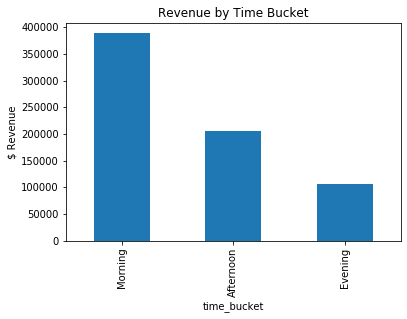

In [88]:
# Revenue by bucket

bucket_revenue=df.groupby('time_bucket')['revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by Time Bucket')
plt.ylabel('$ Revenue')

In [79]:
# Sales Trend Analysis
# Store location Analysis

store_revenue=df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)

print(store_revenue)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64


In [107]:
# Store wise hourly comparision

store_hourly=df.groupby(['store_location','hour'])['revenue'].sum().reset_index()
print(store_hourly.head())

  store_location  hour   revenue
0        Astoria     7  19028.80
1        Astoria     8  22805.90
2        Astoria     9  23183.57
3        Astoria    10  24426.12
4        Astoria    11  15498.13


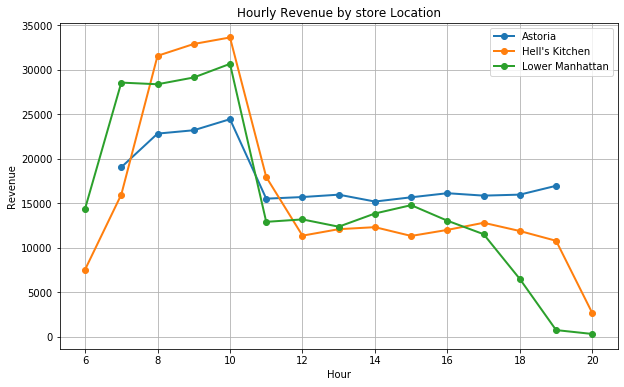

In [106]:
# Store level Temporal Demand Comparision

store_hourly=df.groupby(['store_location','hour'])['revenue'].sum().reset_index()

plt.figure(figsize=(10,6))

for store in store_hourly['store_location'].unique():
    data=store_hourly[store_hourly['store_location']==store]
           
    plt.plot(data['hour'],data['revenue'],marker='o',linewidth=2,label=store)
           
plt.title('Hourly Revenue by Store Location')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

plt.show()
    

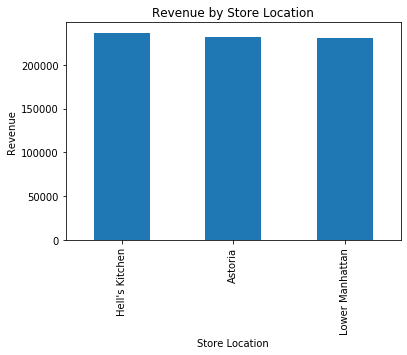

In [82]:
# store level trend comparision

import matplotlib.pyplot as plt

store_revenue.plot(kind='bar')

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue")

plt.show()

In [84]:
# Store wise transaction count

store_txn=df.groupby('store_location')['transaction_id'].count()

print(store_txn)


store_location
Astoria            50599
Hell's Kitchen     50735
Lower Manhattan    47782
Name: transaction_id, dtype: int64


Text(0.5, 0, 'Hour')

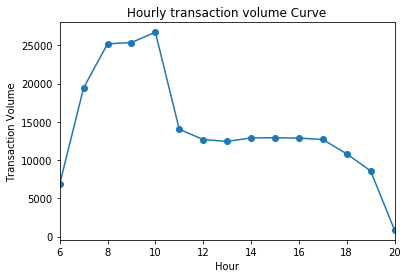

In [35]:
## Time- of Day Demand Analysis
 # Hourly transaction volume
import matplotlib.pyplot as plt

hourly_transactions=df.groupby("hour")["transaction_qty"].sum()
hourly_transactions.plot(kind="line", marker='o')
plt.title("Hourly transaction volume Curve")
plt.ylabel("Transaction Volume")
plt.xlabel("Hour")

Text(0, 0.5, 'Revenue')

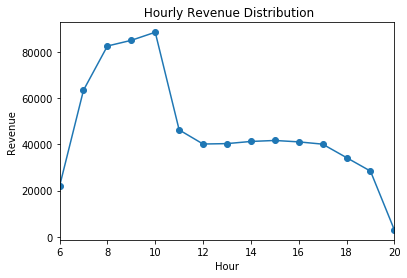

In [36]:
## Hourly Revenue Distribution

hourly_revenue=df.groupby("hour")["revenue"].sum()
hourly_revenue.plot(kind="line", marker='o')
plt.title(" Hourly Revenue Distribution")
plt.xlabel("Hour")
plt.ylabel("Revenue")

In [39]:
# Peak hour Analysis

# Morning  Rush hours

peak_hour=hourly_revenue.idxmax()
peak_revenue=hourly_revenue.max()

print("Peak Hour:", peak_hour)
print("Revenue:", peak_revenue)

Peak Hour: 10
Revenue: 88673.39000000044


In [41]:
# Peak hour

hourly_transactions.idxmax()

10

In [42]:
# lowest activity hour

hourly_transactions.idxmin()

20

In [91]:
print(hourly_revenue)

hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: revenue, dtype: float64


In [ ]:
# Identification of Morning rush hours,mid day slow periods, evening peak hour 


Morning rush hours were observed between 8:00AM and 10:00 AM, with peak revenue generated at 10:00 AM. This indicates strong customer demand during the early business hours.

A noticable decline in revenue was observed during the midday period (12:00 PM- 3:00 PM), indicating reduced customer activity compared to morning peak hours.

Revenue gradually decreased during evening business hours. While customer activity continued after 5:00 PM to 8:00 PM, indicating that the majority of sales occured during the morning hours.

In [ ]:
### Cross location Temporal Comparision
# Compare temporal demand patterns across store locations
# hourly  heatmap per store 
import seaborn as sns

store_hour=df.pivot_table(values="revenue",
                          index="store_location",
                          columns="hour",
                          aggfunc="sum"
                         )
sns.heatmap(store_hour, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Revenue Heatmap by Store And Hour")
plt.xlabel("Hour")
plt.ylabel("Store Location")
plt.show()

In [ ]:
# Peak Hour Alignment or divergence across locations

store_peak=df.groupby("store_location")["hour"].agg(lambda x: x.mode()[0])
store_peak

# Location specific customer behavior insights
 
- Astoria experiences a sharp revenue spike around 7AM, suggesting a strong early-morning customer base.
- Hell's Kitchen maintains consistently highh revenue from 8 AM to 10AM, indicating sustained customer activity during morning hours.
- Lower Manhattan  shows a more balanced demand pattern across peak hours, suggestng relatively stable customer traffic.
- Customer demand patterns vary by location, highlighting the need for store specific operational planning.
- Although all store experience morning demand, the intensity and duration of peak activity differ across locations.


R2 Score: 0.3724306782076868


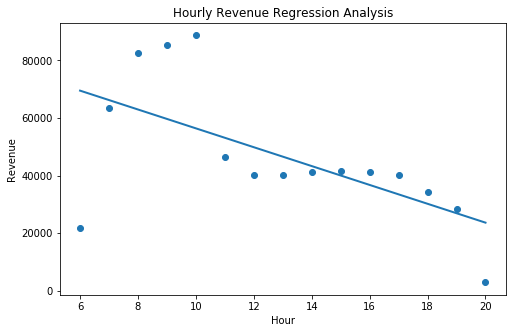

In [45]:
# Regression

from sklearn.linear_model import LinearRegression
import numpy as np

X=hourly_revenue.index.values.reshape(-1,1)
y=hourly_revenue.values

model=LinearRegression()
model.fit(X,y)

print("R2 Score:", model.score(X,y))


#visualizing with graph

plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.plot(X, model.predict(X), linewidth=2)

plt.title("Hourly Revenue Regression Analysis")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

In [63]:
import sys
print(sys.executable)

c:\users\lenovo\appdata\local\programs\python\python37\python.exe


In [66]:
from statsmodels.tsa.arima.model import ARIMA

In [67]:
model =ARIMA(hourly_revenue,order=(1,1,1))
model_fit=model.fit()

print(model_fit.summary())

c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   15
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -155.672
Date:                Mon, 22 Jun 2026   AIC                            317.344
Time:                        12:35:01   BIC                            319.262
Sample:                             0   HQIC                           317.167
                                 - 15                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4734      1.216      0.389      0.697      -1.910       2.856
ma.L1         -0.0167      1.397     -0.012      0.990      -2.754       2.721
sigma2      2.507e+08   1.48e-09    1.7e+17      0.0

In [69]:
forecast=model_fit.forecast(steps=5)
print(forecast)

15    -8759.169435
16   -14295.173842
17   -16915.767617
18   -18156.285367
19   -18743.512698
Name: predicted_mean, dtype: float64


c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


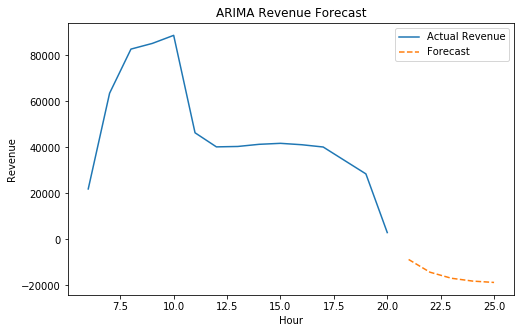

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(hourly_revenue.index, hourly_revenue.values,label='Actual Revenue')

future_hours=range(hourly_revenue.index.max()+1,
                   hourly_revenue.index.max()+6
                  )
plt.plot(future_hours, forecast,'--',label='Forecast')

plt.title("ARIMA Revenue Forecast")
plt.xlabel("Hour")
plt.ylabel('Revenue')
plt.legend()

plt.show()
        

# Recommendations
1. Increase staffing during peak morning hours to efficiently handle customer demand.
2. Maintain adequate inventory levels before morning rush periods.
3. Introduce promotional offers during lower demand periods to improve sales.
4. Implement store specific staffing strategies based on observed demand patterns.
5. Continuously monitor hourly sales performance to optimize operational efficiency.

# Conclusion
This analysis examined temporal sales patterns across Afficionado coffe Roastres locations. The findings revealed that customer demand is strongest during morninghours, with variations in demand intensity across store locations. The results provide valuable insights for staffing optimization, inventory planning, and operational decision making. Due to the absence of transaction date information, daily and weekly trend analysis could not be performed. However, the available hourly analysis still offers actionable business insights.